<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_7_Advanced_Time_Series_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Uploading the Dataset
from google.colab import files
uploaded = files.upload()

Saving ts_data.csv to ts_data.csv


In [2]:
# Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [13]:
# Load the Dataset
df = pd.read_csv("ts_data.csv")

# Converting the Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Setting as index
df.set_index('Timestamp', inplace=True)

# Displaying the first rows
df.head()

,Load,Temp
Timestamp,,
2023-01-01 00:00:00,768.7,4.6
2023-01-01 01:00:00,787.5,1.9
2023-01-01 02:00:00,813.3,4.4
2023-01-01 03:00:00,831.5,7.3
2023-01-01 04:00:00,752.3,10.1


In [4]:
# Basic Dataset Information
# Dataset shape
print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2160, 2)

Data Types:
Load    float64
Temp    float64
dtype: object


In [6]:
# Summary Statistics
df[['Load','Temp']].describe()

,Load,Temp
count,2160.000000,2160.000000
mean,688.788380,13.113194
std,124.332049,4.362963
min,378.200000,1.900000
25%,591.700000,9.800000
50%,686.400000,13.050000
75%,788.800000,16.500000
max,1026.400000,25.500000


In [14]:
# Checking for Missing Values
df.isnull().sum()

,0
Load,0
Temp,0


In [15]:
# Handling the Missing Values
# Filling the missing values using forward fill
df.fillna(method='ffill', inplace=True)

# Verifying it again
df.isnull().sum()

/tmp/ipykernel_168/2436465170.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,0
Load,0
Temp,0


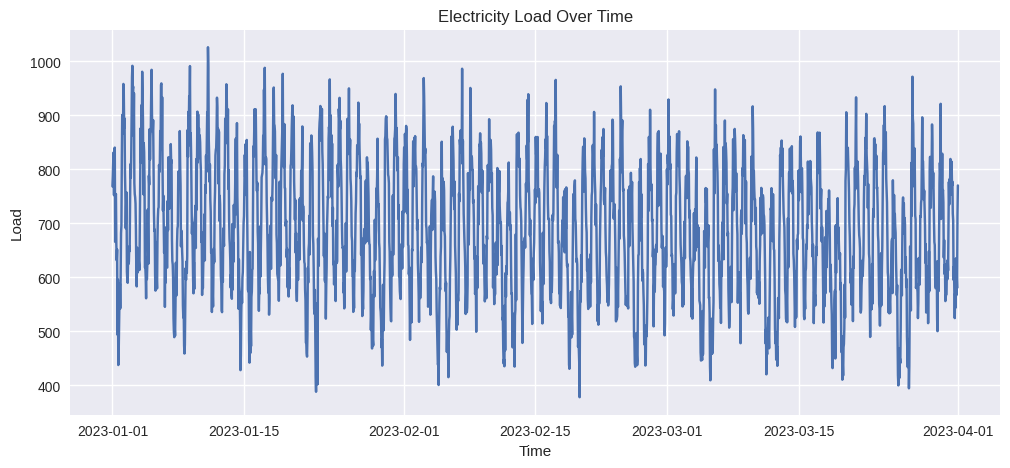

In [16]:
# Data Visualization
# Plotting Load Over Time
plt.figure(figsize=(12,5))
plt.plot(df['Load'])
plt.title("Electricity Load Over Time")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

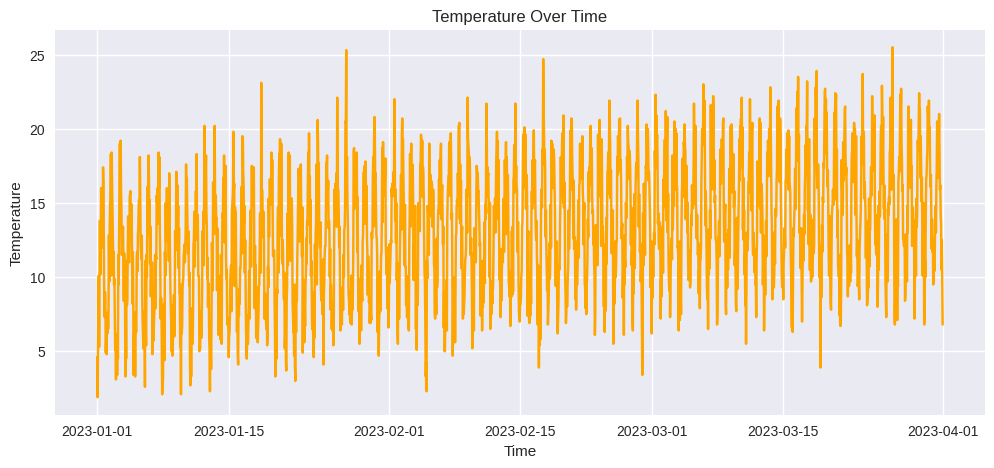

In [17]:
# Plotting the Temperature Over Time
plt.figure(figsize=(12,5))
plt.plot(df['Temp'], color='orange')
plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

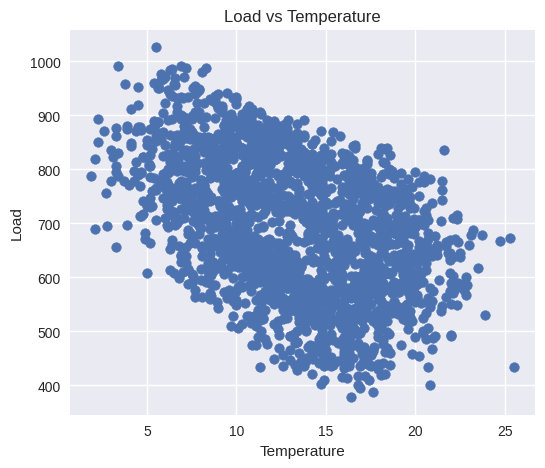

In [12]:
# Scatter Plot - Load vs Temp
plt.figure(figsize=(6,5))
plt.scatter(df['Temp'], df['Load'])
plt.xlabel("Temperature")
plt.ylabel("Load")
plt.title("Load vs Temperature")
plt.show()

In [18]:
# Date-Time Feature Engineering
# Extracting Date-Time Features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

df.head()

,Load,Temp,Hour,DayOfWeek,Month
Timestamp,,,,,
2023-01-01 00:00:00,768.7,4.6,0,6,1
2023-01-01 01:00:00,787.5,1.9,1,6,1
2023-01-01 02:00:00,813.3,4.4,2,6,1
2023-01-01 03:00:00,831.5,7.3,3,6,1
2023-01-01 04:00:00,752.3,10.1,4,6,1


In [19]:
# Weekend Feature
df['Is_Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

In [20]:
# Holiday Feature
# Example holiday list
holidays = ['2023-01-01','2023-12-25']

df['Is_Holiday'] = df.index.strftime('%Y-%m-%d').isin(holidays).astype(int)

In [21]:
# Season Feature
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df['Season'] = df['Month'].apply(get_season)

In [22]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['DayOfWeek','Month','Season'], drop_first=True)

df.head()

,Load,Temp,Hour,Is_Weekend,Is_Holiday,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,Month_2,Month_3,Season_Winter
Timestamp,,,,,,,,,,,,,,
2023-01-01 00:00:00,768.7,4.6,0,1,1,False,False,False,False,False,True,False,False,True
2023-01-01 01:00:00,787.5,1.9,1,1,1,False,False,False,False,False,True,False,False,True
2023-01-01 02:00:00,813.3,4.4,2,1,1,False,False,False,False,False,True,False,False,True
2023-01-01 03:00:00,831.5,7.3,3,1,1,False,False,False,False,False,True,False,False,True
2023-01-01 04:00:00,752.3,10.1,4,1,1,False,False,False,False,False,True,False,False,True


In [24]:
# Lagging Features
# Creating Lag Features
df['Load_Lag1'] = df['Load'].shift(1)
df['Load_Lag24'] = df['Load'].shift(24)
df['Load_Lag168'] = df['Load'].shift(168)

df.head()

,Load,Temp,Hour,Is_Weekend,Is_Holiday,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,Month_2,Month_3,Season_Winter,Load_Lag1,Load_Lag24,Load_Lag168
Timestamp,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,768.7,4.6,0,1,1,False,False,False,False,False,True,False,False,True,NaN,NaN,NaN
2023-01-01 01:00:00,787.5,1.9,1,1,1,False,False,False,False,False,True,False,False,True,768.7,NaN,NaN
2023-01-01 02:00:00,813.3,4.4,2,1,1,False,False,False,False,False,True,False,False,True,787.5,NaN,NaN
2023-01-01 03:00:00,831.5,7.3,3,1,1,False,False,False,False,False,True,False,False,True,813.3,NaN,NaN
2023-01-01 04:00:00,752.3,10.1,4,1,1,False,False,False,False,False,True,False,False,True,831.5,NaN,NaN


In [25]:
# Nested Lag Features
df['Load_Past_24H_Mean'] = df['Load'].shift(1).rolling(window=24).mean()

df['Load_Past_7D_Max'] = df['Load'].shift(1).rolling(window=168).max()

df['Load_Past_30D_Min'] = df['Load'].shift(1).rolling(window=720).min()

In [26]:
# Handling the Lag Missing Values
df.dropna(inplace=True)

df.head()

,Load,Temp,Hour,Is_Weekend,Is_Holiday,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,Month_2,Month_3,Season_Winter,Load_Lag1,Load_Lag24,Load_Lag168,Load_Past_24H_Mean,Load_Past_7D_Max,Load_Past_30D_Min
Timestamp,,,,,,,,,,,,,,,,,,,,
2023-01-31 00:00:00,857.0,6.9,0,0,0,True,False,False,False,False,False,False,False,True,794.5,855.5,856.7,730.158333,966.8,388.3
2023-01-31 01:00:00,860.2,7.9,1,0,0,True,False,False,False,False,False,False,False,True,857.0,861.8,878.8,730.220833,966.8,388.3
2023-01-31 02:00:00,875.2,10.4,2,0,0,True,False,False,False,False,False,False,False,True,860.2,894.1,866.5,730.154167,966.8,388.3
2023-01-31 03:00:00,939.9,7.7,3,0,0,True,False,False,False,False,False,False,False,True,875.2,898.6,966.8,729.366667,966.8,388.3
2023-01-31 04:00:00,892.5,9.4,4,0,0,True,False,False,False,False,False,False,False,True,939.9,896.8,845.4,731.087500,950.2,388.3


In [27]:
# Rolling Window Statistics
# Rolling Statistics
df['Load_Rolling_Mean_3H'] = df['Load'].rolling(window=3).mean()

df['Load_Rolling_Std_6H'] = df['Load'].rolling(window=6).std()

df['Load_Rolling_Median_12H'] = df['Load'].rolling(window=12).median()

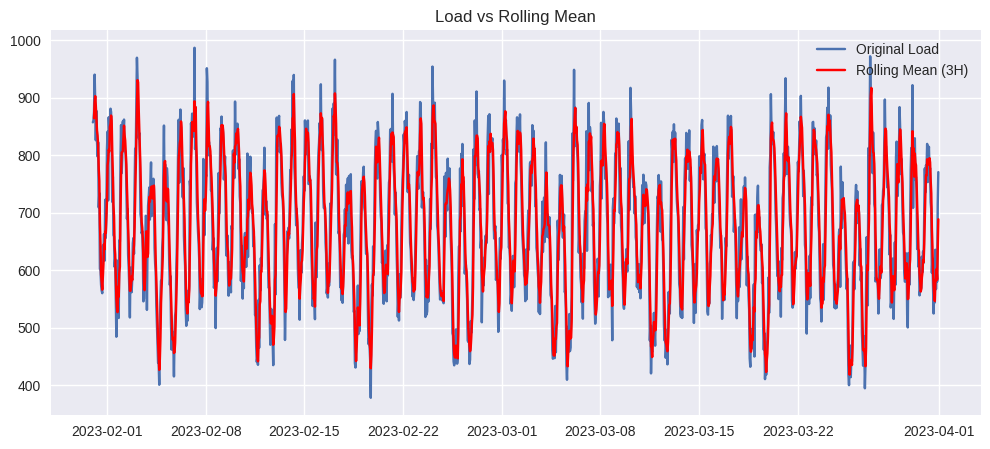

In [28]:
# Plotting Rolling Mean
plt.figure(figsize=(12,5))

plt.plot(df['Load'], label='Original Load')
plt.plot(df['Load_Rolling_Mean_3H'], label='Rolling Mean (3H)', color='red')

plt.legend()
plt.title("Load vs Rolling Mean")
plt.show()

In [29]:
# Expanding Window Statistics
# Expanding Statistics
df['Load_Expanding_Mean'] = df['Load'].expanding().mean()

df['Load_Expanding_Max'] = df['Load'].expanding().max()

df['Load_Expanding_Min'] = df['Load'].expanding().min()

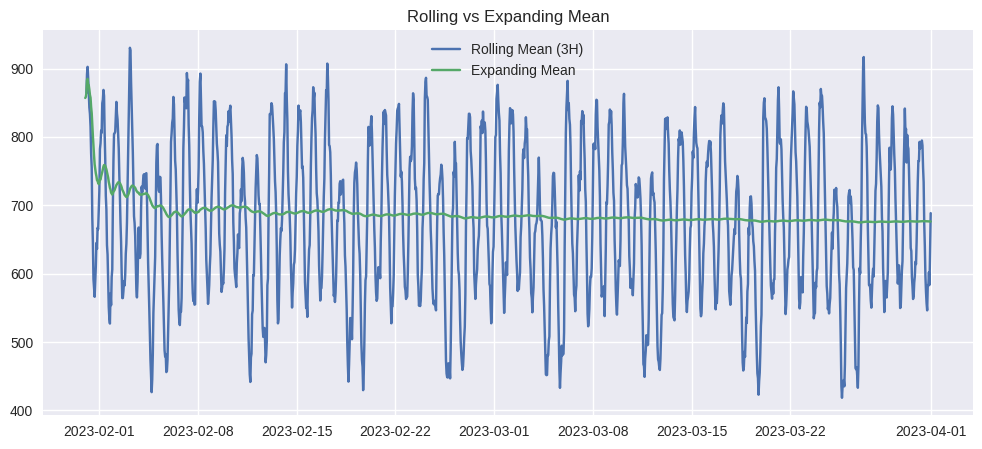

In [30]:
# Comparing Expanding vs Rolling Mean
plt.figure(figsize=(12,5))

plt.plot(df['Load_Rolling_Mean_3H'], label="Rolling Mean (3H)")
plt.plot(df['Load_Expanding_Mean'], label="Expanding Mean")

plt.legend()
plt.title("Rolling vs Expanding Mean")
plt.show()

In [31]:
# Correlation Analysis with Correlation Matrix
corr_matrix = df.corr()

corr_matrix.head()

,Load,Temp,Hour,Is_Weekend,Is_Holiday,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,...,Load_Lag168,Load_Past_24H_Mean,Load_Past_7D_Max,Load_Past_30D_Min,Load_Rolling_Mean_3H,Load_Rolling_Std_6H,Load_Rolling_Median_12H,Load_Expanding_Mean,Load_Expanding_Max,Load_Expanding_Min
Load,1.000000,-0.392118,-6.626308e-01,-3.766454e-01,NaN,9.587237e-02,9.266657e-02,8.932321e-02,1.022403e-01,-2.499383e-01,...,0.882526,0.276941,0.076172,0.013400,0.931447,0.211666,0.237211,0.128684,-0.083153,0.123597
Temp,-0.392118,1.000000,8.027899e-02,-2.642236e-03,NaN,-3.674273e-03,1.193492e-02,2.280259e-04,-9.269135e-03,-4.187916e-03,...,-0.319391,-0.039276,-0.102351,-0.005390,-0.156067,-0.226056,0.603707,-0.076906,0.115266,-0.102044
Hour,-0.662631,0.080279,1.000000e+00,-6.971648e-17,NaN,6.151149e-17,1.110451e-17,1.023112e-17,-1.497237e-18,-4.370839e-17,...,-0.660900,-0.003623,-0.000338,0.003253,-0.712179,-0.307208,-0.230261,-0.075124,0.034408,-0.061911
Is_Weekend,-0.376645,-0.002642,-6.971648e-17,1.000000e+00,NaN,-2.533202e-01,-2.533202e-01,-2.533202e-01,-2.533202e-01,6.504436e-01,...,-0.370785,-0.704860,-0.107802,-0.035615,-0.387064,-0.069427,-0.411278,-0.078642,0.079937,-0.078705
Is_Holiday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


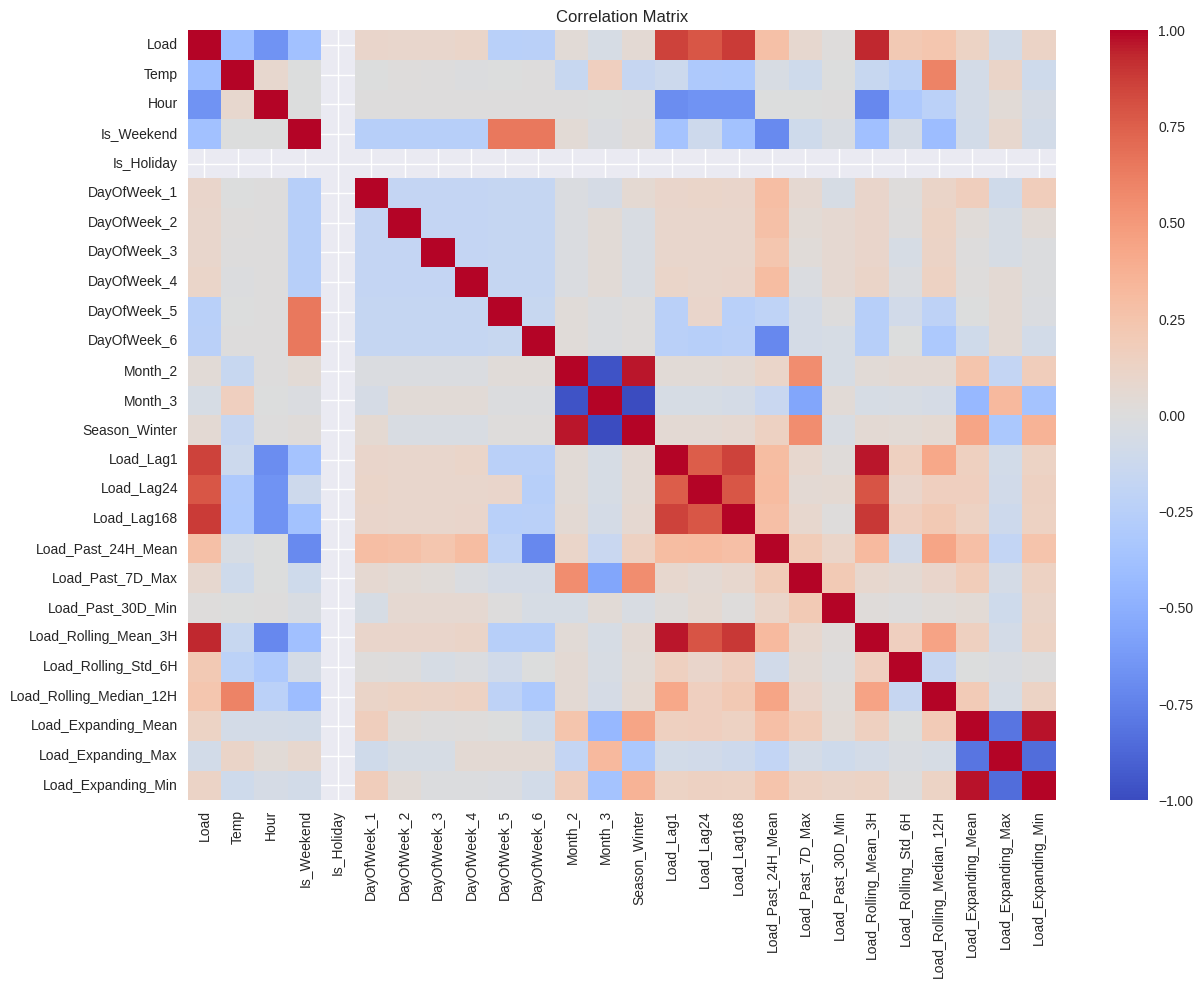

In [32]:
# Heatmap Visualization
plt.figure(figsize=(14,10))

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [33]:
# Correlation With Target
corr_matrix['Load'].sort_values(ascending=False)

,Load
Load,1.000000
Load_Rolling_Mean_3H,0.931447
Load_Lag168,0.882526
Load_Lag1,0.858668
Load_Lag24,0.785259
Load_Past_24H_Mean,0.276941
Load_Rolling_Median_12H,0.237211
Load_Rolling_Std_6H,0.211666
Load_Expanding_Mean,0.128684
Load_Expanding_Min,0.123597


In [34]:
# Preparing the Dataset for Machine Learning
# Feature Selection
features = df.drop(columns=['Load'])

target = df['Load']

print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (1440, 25)
Target shape: (1440,)


In [35]:
# Final Dataset
final_df = df.copy()

final_df.head()

,Load,Temp,Hour,Is_Weekend,Is_Holiday,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,...,Load_Lag168,Load_Past_24H_Mean,Load_Past_7D_Max,Load_Past_30D_Min,Load_Rolling_Mean_3H,Load_Rolling_Std_6H,Load_Rolling_Median_12H,Load_Expanding_Mean,Load_Expanding_Max,Load_Expanding_Min
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-31 00:00:00,857.0,6.9,0,0,0,True,False,False,False,False,...,856.7,730.158333,966.8,388.3,NaN,NaN,NaN,857.000000,857.0,857.0
2023-01-31 01:00:00,860.2,7.9,1,0,0,True,False,False,False,False,...,878.8,730.220833,966.8,388.3,NaN,NaN,NaN,858.600000,860.2,857.0
2023-01-31 02:00:00,875.2,10.4,2,0,0,True,False,False,False,False,...,866.5,730.154167,966.8,388.3,864.133333,NaN,NaN,864.133333,875.2,857.0
2023-01-31 03:00:00,939.9,7.7,3,0,0,True,False,False,False,False,...,966.8,729.366667,966.8,388.3,891.766667,NaN,NaN,883.075000,939.9,857.0
2023-01-31 04:00:00,892.5,9.4,4,0,0,True,False,False,False,False,...,845.4,731.087500,950.2,388.3,902.533333,NaN,NaN,884.960000,939.9,857.0


In [36]:
# Saving the Engineered Dataset
# Save Dataset
final_df.to_csv("engineered_timeseries_dataset.csv")

print("Dataset saved successfully!")

Dataset saved successfully!
